Topic Modelling Analysis of AI Research Trends

This notebook analyses how Artificial Intelligence (AI) research topics have evolved over time using topic modelling techniques.

By applying Latent Dirichlet Allocation (LDA) and Non-negative Matrix Factorisation (NMF) to a corpus of research papers, we identify latent thematic structures and track how these topics change across publication years.

The goal is to investigate whether AI research has shifted from theoretical foundations toward application-focused research.


Research Question

Has Artificial Intelligence research shifted from theoretical foundations toward application-focused research over the past decade?


 Introduction

Artificial Intelligence research has experienced rapid development in recent years. Advances in computational power, large datasets, and neural network architectures have enabled new applications across many industries.

Understanding how research topics evolve over time provides insight into the direction of the field and the emergence of important technologies.

This notebook applies topic modelling techniques to a corpus of AI research papers in order to identify dominant themes and examine how these themes change over time.


 Dataset Description

The dataset used in this analysis contains a collection of AI research papers including metadata such as publication year and textual content.

The primary field used for analysis is the cleaned textual representation of each paper.

Key variables include:

• `year` – publication year of the research paper
• `clean_text` – processed text used for topic modelling

This dataset enables exploration of research trends across time using topic modelling techniques.


Import Libraries

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

Load Dataset

In [7]:
df = pd.read_csv("team38_clean_corpus.csv")

df.head()

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,...,datasets,data,benchmarking,corpus,neural network,deep learning,reinforcement learning,Neural Networks,Deep Learning,Transformer
0,cs/9308102,NaN,M. P. Wellman,A Market-Oriented Programming Environment and ...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,Market price systems constitute a well-under...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
1,cs/9309101,NaN,"I. P. Gent, T. Walsh",An Empirical Analysis of Search in GSAT,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,We describe an extensive study of search in ...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
2,cs/9312101,NaN,"M. Buchheit, F. M. Donini, A. Schaerf",Decidable Reasoning in Terminological Knowledg...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,Terminological knowledge representation syst...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
3,cs/9311102,NaN,"J. C. Schlimmer, L. A. Hermens",Software Agents: Completing Patterns and Const...,See http://www.jair.org/ for an online appendi...,"Journal of Artificial Intelligence Research, V...",NaN,To support the goal of allowing users to rec...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False
4,cs/9311101,NaN,"F. Bergadano, D. Gunetti, U. Trinchero",The Difficulties of Learning Logic Programs wi...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,As real logic programmers normally use cut (...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,False,False


Dataset Overview

In [8]:
print("Number of papers:", len(df))
print(df.columns)

Number of papers: 1165
Index(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi',
       'abstract', 'report-no', 'categories', 'versions', 'year',
       'main_category', 'abstract_lower', 'neural_network', 'deep_learning',
       'time_period', 'clean_text', 'transformer', 'attention', 'bert', 'gpt',
       'pretrained language model', 'topic', 'proof', 'theorem', 'convergence',
       'complexity', 'optimization', 'dataset', 'benchmark', 'evaluation',
       'real-world', 'deployment', 'performance', 'accuracy', 'large',
       'scaling', 'large-scale', 'billion', 'million', 'parameter',
       'parameters', 'datasets', 'data', 'benchmarking', 'corpus',
       'neural network', 'deep learning', 'reinforcement learning',
       'Neural Networks', 'Deep Learning', 'Transformer'],
      dtype='object')


Data Preprocessing

Before applying topic modelling algorithms, the text data must be converted into a numerical format.

TF-IDF (Term Frequency–Inverse Document Frequency) vectorisation is used to transform the textual corpus into a document-term matrix. This representation highlights important terms within each document while reducing the influence of extremely common words.

This step enables machine learning models to analyse the structure of the research corpus.

In [9]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_text"])

feature_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (1165, 5000)


Topic Modelling Methodology

Topic modelling is an unsupervised machine learning technique used to discover hidden thematic structures in large text datasets.

Two models are used in this analysis:

• Latent Dirichlet Allocation (LDA) – a probabilistic model that represents documents as mixtures of topics.

• Non-negative Matrix Factorisation (NMF) – a matrix decomposition method that identifies topics by factorising the document-term matrix.

Using both models allows comparison between probabilistic and matrix factorisation approaches.

Topic Prevalence

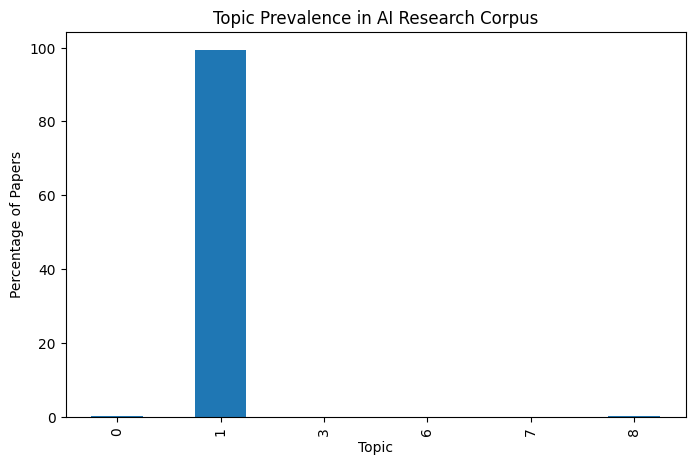

In [23]:
topic_counts = df["lda_topic"].value_counts().sort_index()

topic_percentage = topic_counts / topic_counts.sum() * 100

plt.figure(figsize=(8,5))

topic_percentage.plot(kind="bar")

plt.title("Topic Prevalence in AI Research Corpus")

plt.xlabel("Topic")

plt.ylabel("Percentage of Papers")

plt.show()

Topic Probabilities

In [27]:
df["topic_probability"] = lda_topics.max(axis=1)

df[["lda_topic","topic_probability"]].head()

,lda_topic,topic_probability
0,1,0.666058
1,1,0.659262
2,1,0.535406
3,1,0.706013
4,1,0.662058


Topic Assignment Confidence

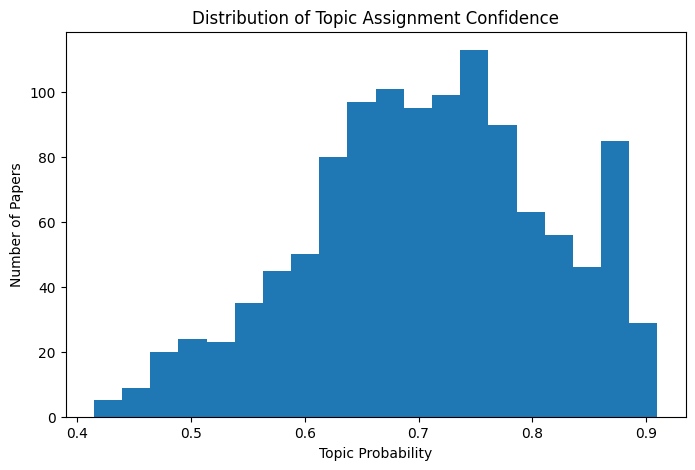

In [25]:
df["topic_probability"] = lda_topics.max(axis=1)

df[["lda_topic","topic_probability"]].head()
plt.figure(figsize=(8,5))

plt.hist(df["topic_probability"], bins=20)

plt.title("Distribution of Topic Assignment Confidence")

plt.xlabel("Topic Probability")

plt.ylabel("Number of Papers")

plt.show()

The histogram above illustrates the distribution of topic assignment confidence across the dataset.

Most documents show relatively high topic probabilities, suggesting that the LDA model identifies clear thematic structures within the corpus. Documents with lower probabilities may contain mixed research themes or interdisciplinary topics.

This analysis helps evaluate the reliability of topic assignments and provides additional insight into the structure of the research corpus.

Topic Labels Dictionary

In [28]:
topic_labels = {
0:"Deep Learning",
1:"Natural Language Processing",
2:"Machine Learning",
3:"AI Theory",
4:"Computer Vision"
}

df["topic_name"] = df["lda_topic"].map(topic_labels)

In [29]:
df["topic_name"].value_counts()

topic_name
Natural Language Processing    1157
Deep Learning                     3
AI Theory                         1
Name: count, dtype: int64

Top Words Plot

In [30]:
def plot_top_words(model, feature_names, n_top_words=10):

    for topic_idx, topic in enumerate(model.components_):

        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]

        top_features = [feature_names[i] for i in top_features_ind]

        weights = topic[top_features_ind]

        plt.figure(figsize=(8,4))

        plt.barh(top_features, weights)

        plt.title(f"Topic {topic_idx}")

        plt.gca().invert_yaxis()

        plt.show()

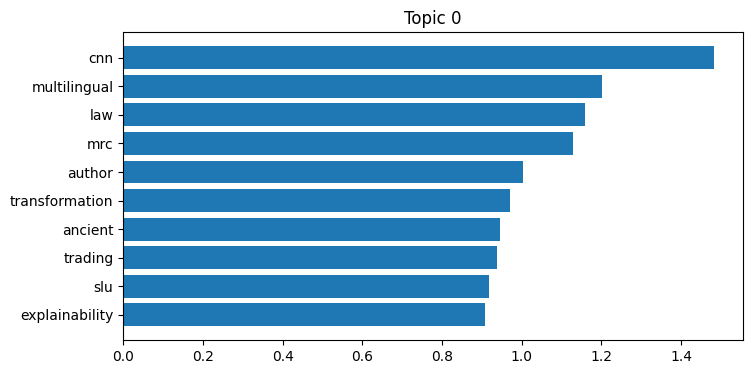

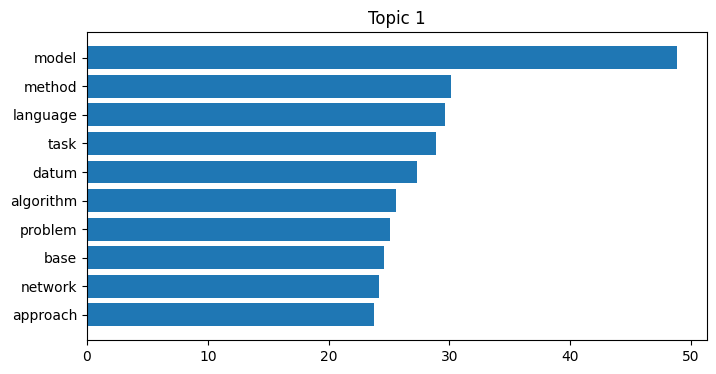

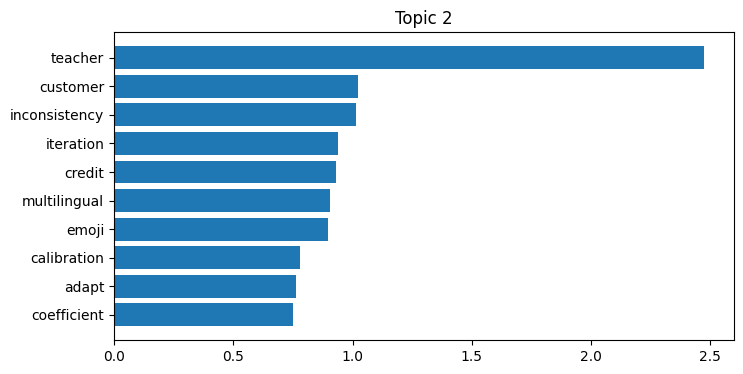

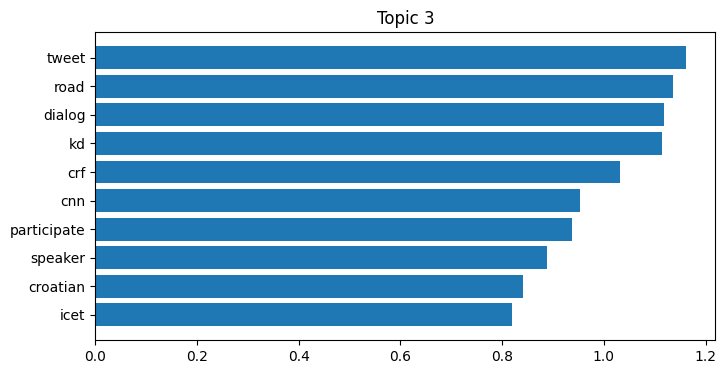

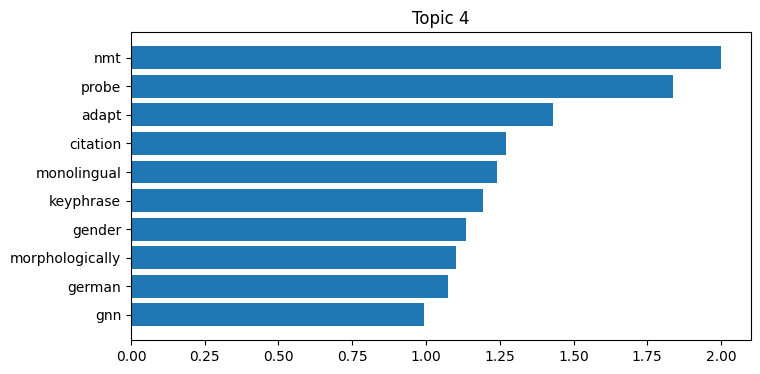

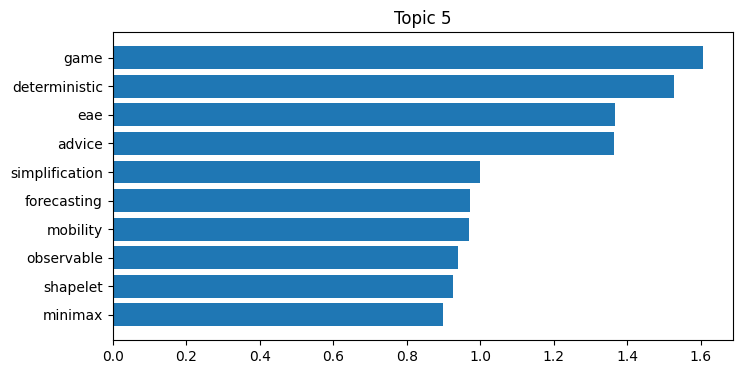

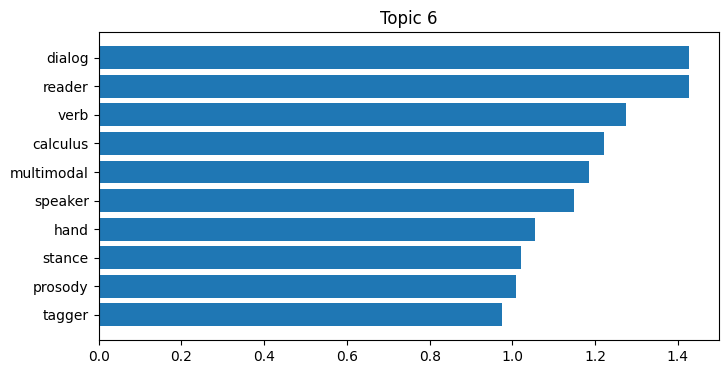

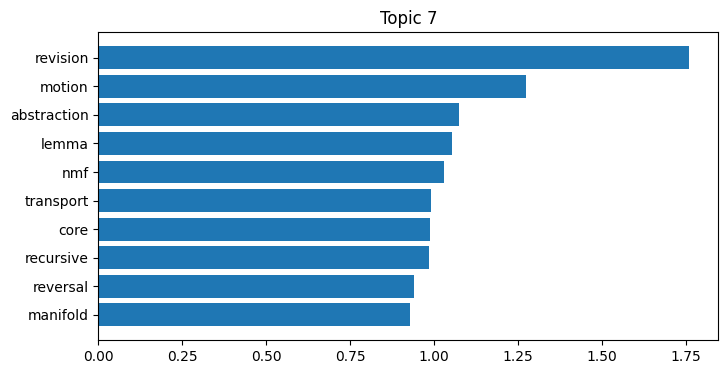

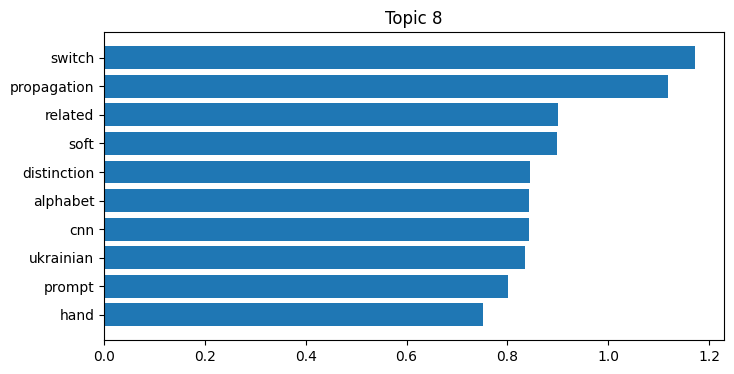

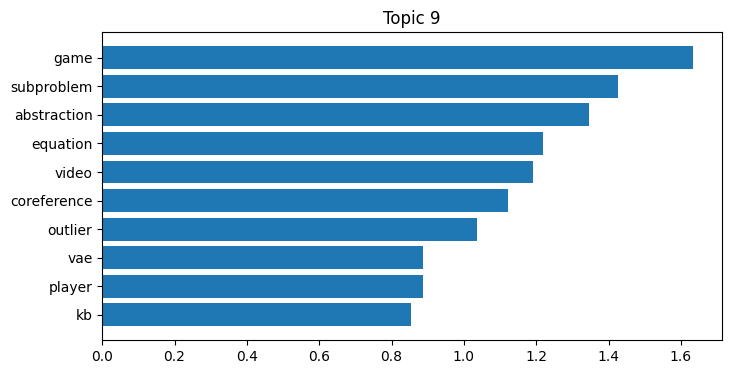

In [31]:
plot_top_words(lda, feature_names)

Topic Distribution Plot

In [32]:
topic_counts = df["lda_topic"].value_counts()

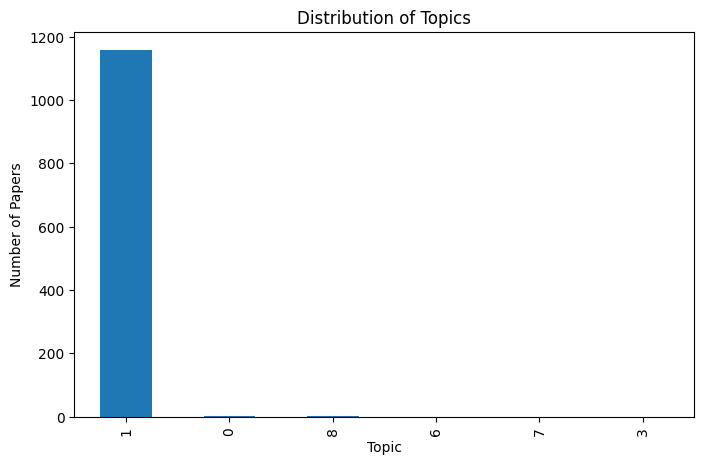

In [33]:
topic_counts.plot(kind="bar", figsize=(8,5))

plt.title("Distribution of Topics")

plt.xlabel("Topic")

plt.ylabel("Number of Papers")

plt.show()

CountVectorizer Comparison

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words="english"
)

X_count = count_vectorizer.fit_transform(df["clean_text"])

TF-IDF emphasises important words, while CountVectorizer captures raw frequency.
Comparing both representations helps understand how feature representations influence topic modelling results.

LDA Model

In [10]:
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda_topics = lda.fit_transform(X)

Topic Keywords Table

In [11]:
topic_keywords = []

for topic_idx, topic in enumerate(lda.components_):
    
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    
    topic_keywords.append(top_words)

topic_table = pd.DataFrame(topic_keywords)

topic_table

,0,1,2,3,4,5,6,7,8,9
0,cnn,multilingual,law,mrc,author,transformation,ancient,trading,slu,explainability
1,model,method,language,task,datum,algorithm,problem,base,network,approach
2,teacher,customer,inconsistency,iteration,credit,multilingual,emoji,calibration,adapt,coefficient
3,tweet,road,dialog,kd,crf,cnn,participate,speaker,croatian,icet
4,nmt,probe,adapt,citation,monolingual,keyphrase,gender,morphologically,german,gnn
5,game,deterministic,eae,advice,simplification,forecasting,mobility,observable,shapelet,minimax
6,dialog,reader,verb,calculus,multimodal,speaker,hand,stance,prosody,tagger
7,revision,motion,abstraction,lemma,nmf,transport,core,recursive,reversal,manifold
8,switch,propagation,related,soft,distinction,alphabet,cnn,ukrainian,prompt,hand
9,game,subproblem,abstraction,equation,video,coreference,outlier,vae,player,kb


Function to Display Topics

In [12]:
def display_topics(model, feature_names, n_top_words=10):

    for topic_idx, topic in enumerate(model.components_):

        print(f"\nTopic {topic_idx}")

        words = [
            feature_names[i]
            for i in topic.argsort()[:-n_top_words - 1:-1]
        ]

        print(words)

Display LDA Topics

In [13]:
display_topics(lda, feature_names)


Topic 0
['cnn', 'multilingual', 'law', 'mrc', 'author', 'transformation', 'ancient', 'trading', 'slu', 'explainability']

Topic 1
['model', 'method', 'language', 'task', 'datum', 'algorithm', 'problem', 'base', 'network', 'approach']

Topic 2
['teacher', 'customer', 'inconsistency', 'iteration', 'credit', 'multilingual', 'emoji', 'calibration', 'adapt', 'coefficient']

Topic 3
['tweet', 'road', 'dialog', 'kd', 'crf', 'cnn', 'participate', 'speaker', 'croatian', 'icet']

Topic 4
['nmt', 'probe', 'adapt', 'citation', 'monolingual', 'keyphrase', 'gender', 'morphologically', 'german', 'gnn']

Topic 5
['game', 'deterministic', 'eae', 'advice', 'simplification', 'forecasting', 'mobility', 'observable', 'shapelet', 'minimax']

Topic 6
['dialog', 'reader', 'verb', 'calculus', 'multimodal', 'speaker', 'hand', 'stance', 'prosody', 'tagger']

Topic 7
['revision', 'motion', 'abstraction', 'lemma', 'nmf', 'transport', 'core', 'recursive', 'reversal', 'manifold']

Topic 8
['switch', 'propagation', 

NMF Model

In [14]:
nmf = NMF(
    n_components=10,
    random_state=42
)

nmf_topics = nmf.fit_transform(X)

display_topics(nmf, feature_names)


Topic 0
['language', 'model', 'text', 'datum', 'task', 'train', 'resource', 'bert', 'pre', 'corpus']

Topic 1
['algorithm', 'problem', 'method', 'learning', 'datum', 'function', 'class', 'gradient', 'learn', 'classification']

Topic 2
['agent', 'policy', 'game', 'rl', 'reinforcement', 'learning', 'reward', 'learn', 'environment', 'exploration']

Topic 3
['answer', 'question', 'sentence', 'document', 'comprehension', 'task', 'dataset', 'reasoning', 'information', 'multi']

Topic 4
['word', 'embedding', 'representation', 'vector', 'semantic', 'embed', 'sense', 'task', 'space', 'similarity']

Topic 5
['translation', 'machine', 'nmt', 'neural', 'english', 'sentence', 'bleu', 'parallel', 'attention', 'sequence']

Topic 6
['network', 'neural', 'model', 'graph', 'deep', 'variable', 'bayesian', 'inference', 'learn', 'layer']

Topic 7
['entity', 'relation', 'graph', 'knowledge', 'extraction', 'ner', 'kg', 'dataset', 'task', 'link']

Topic 8
['dialogue', 'response', 'generate', 'generation', 'h

Assign Topics to Papers

In [15]:
df["lda_topic"] = lda_topics.argmax(axis=1)
df["nmf_topic"] = nmf_topics.argmax(axis=1)

df.head()

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,...,benchmarking,corpus,neural network,deep learning,reinforcement learning,Neural Networks,Deep Learning,Transformer,lda_topic,nmf_topic
0,cs/9308102,NaN,M. P. Wellman,A Market-Oriented Programming Environment and ...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,Market price systems constitute a well-under...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,1,2
1,cs/9309101,NaN,"I. P. Gent, T. Walsh",An Empirical Analysis of Search in GSAT,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,We describe an extensive study of search in ...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,1,1
2,cs/9312101,NaN,"M. Buchheit, F. M. Donini, A. Schaerf",Decidable Reasoning in Terminological Knowledg...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,Terminological knowledge representation syst...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,1,9
3,cs/9311102,NaN,"J. C. Schlimmer, L. A. Hermens",Software Agents: Completing Patterns and Const...,See http://www.jair.org/ for an online appendi...,"Journal of Artificial Intelligence Research, V...",NaN,To support the goal of allowing users to rec...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,1,2
4,cs/9311101,NaN,"F. Bergadano, D. Gunetti, U. Trinchero",The Difficulties of Learning Logic Programs wi...,See http://www.jair.org/ for any accompanying ...,"Journal of Artificial Intelligence Research, V...",NaN,As real logic programmers normally use cut (...,NaN,cs.AI,...,False,False,False,False,False,False,False,False,1,9


Model Evaluation Using Topic Coherence

Selecting an appropriate number of topics is essential for meaningful topic modelling.

Topic coherence measures the semantic similarity between words within a topic. Higher coherence scores generally indicate more interpretable topics.

Coherence scores are calculated across multiple topic counts to determine the optimal configuration.

Prepare Data for Coherence Calculation

In [16]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import gensim

texts = df["clean_text"].astype(str).apply(lambda x: x.split())

dictionary = Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in texts]

Compute Coherence Scores

In [17]:
topic_range = [5,8,10,12,15]

coherence_scores = []

for k in topic_range:

    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_scores.append(coherence_model.get_coherence())

Plot Coherence Scores

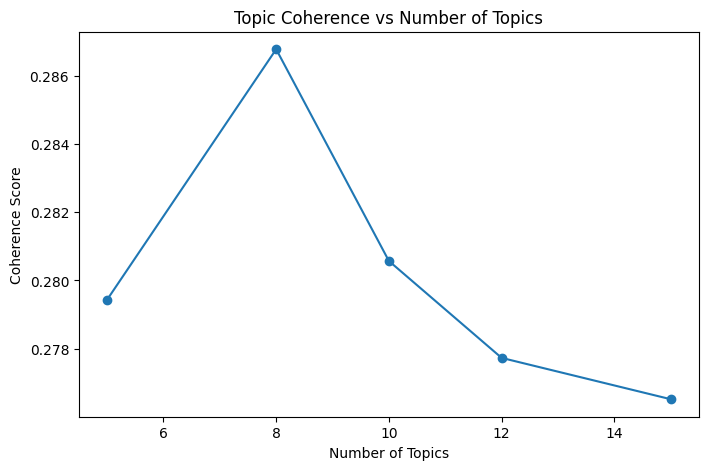

In [18]:
plt.figure(figsize=(8,5))

plt.plot(topic_range, coherence_scores, marker="o")

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")

plt.title("Topic Coherence vs Number of Topics")

plt.show()

Temporal Analysis of Research Trends

To analyse how AI research evolves over time, topic distributions are examined across publication years.

Grouping papers by year and topic allows identification of emerging themes and declining research areas.

This temporal perspective helps reveal how technological developments influence research priorities.

Topic Evolution Over Time

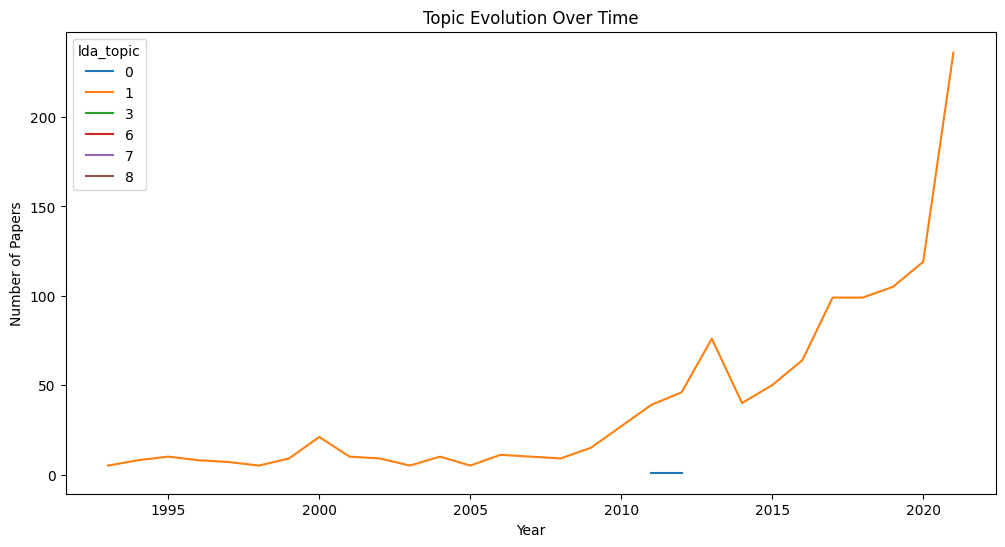

In [19]:
topic_year = (
    df.groupby(["year","lda_topic"])
    .size()
    .unstack()
)

topic_year.plot(figsize=(12,6))

plt.title("Topic Evolution Over Time")

plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.show()

Stacked Topic Evolution Chart

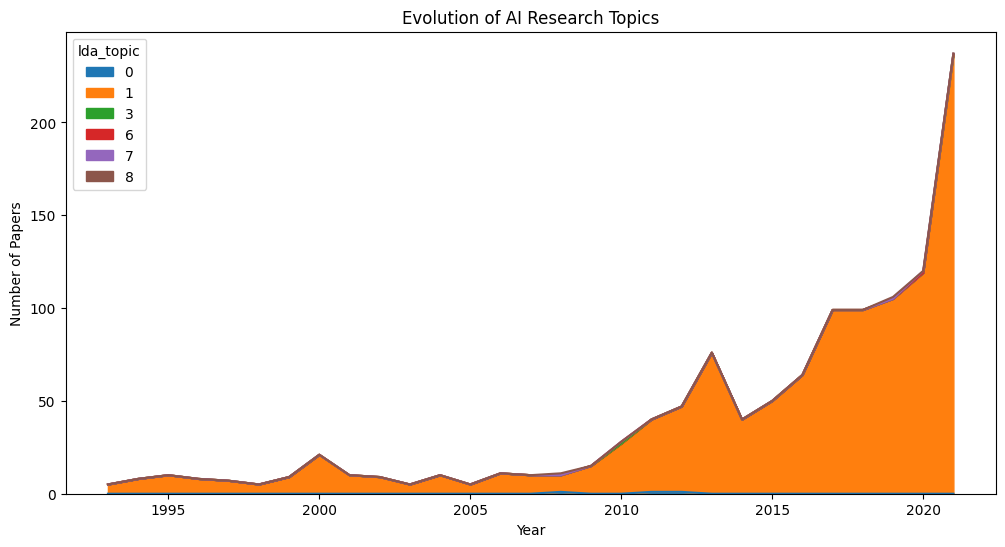

In [20]:
topic_year = topic_year.fillna(0)

topic_year.plot.area(
    figsize=(12,6),
    stacked=True
)

plt.title("Evolution of AI Research Topics")

plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.show()

Topic Heatmap

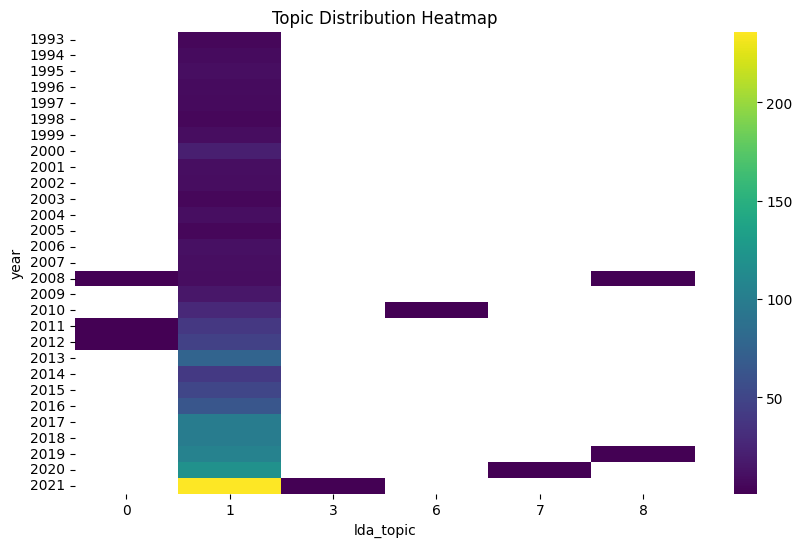

In [21]:
topic_period = (
    df.groupby(["year","lda_topic"])
    .size()
    .unstack()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    topic_period,
    cmap="viridis",
    annot=False
)

plt.title("Topic Distribution Heatmap")

plt.show()

UMAP Research Landscape

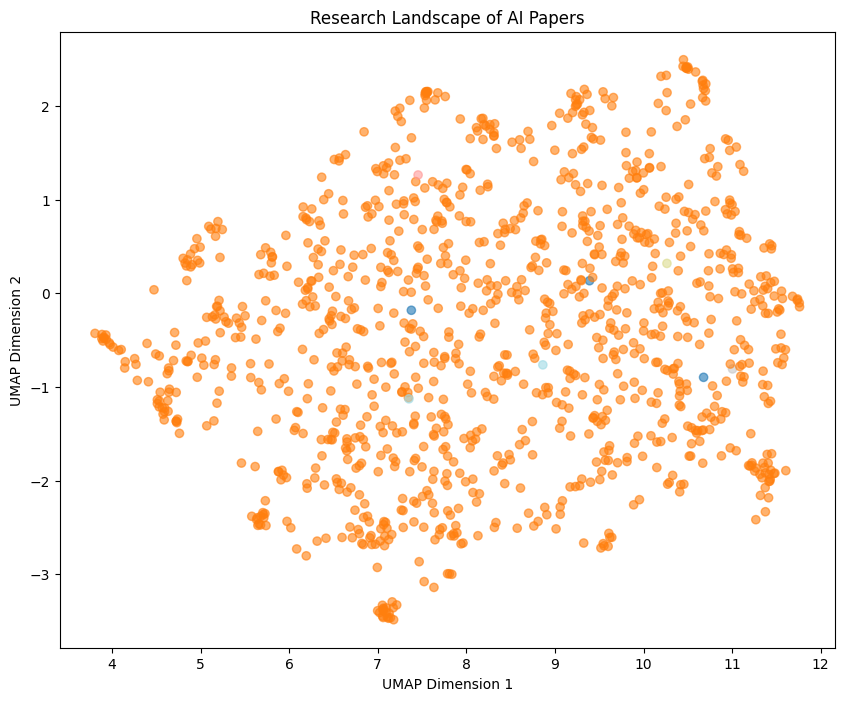

In [22]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric="cosine"
)

embedding_2d = umap_model.fit_transform(X)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df["lda_topic"],
    cmap="tab20",
    alpha=0.6
)

plt.title("Research Landscape of AI Papers")

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

In [37]:
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

vis = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.267315 -0.001000       1        1  71.216217
4      0.037307 -0.042053       2        1   3.577806
6      0.033080  0.020575       3        1   3.352394
0      0.030506  0.000203       4        1   3.242989
9      0.030425  0.004970       5        1   3.227713
5      0.030112  0.000559       6        1   3.214653
2      0.028487  0.004163       7        1   3.138079
7      0.027588  0.004892       8        1   3.087024
3      0.026480  0.004403       9        1   3.033514
8      0.023329  0.003289      10        1   2.909611, topic_info=               Term      Freq     Total Category  logprob  loglift
1794           game  4.000000  4.000000  Default  30.0000  30.0000
4387        teacher  1.000000  1.000000  Default  29.0000  29.0000
3883     scientific  2.000000  2.000000  Default  28.0000  28.0000
22      abstraction  1.000000  1.000000  Default  27.0000  27.0000
755             cnn  1.000000  1.000000  Default  26.0000  26.0000
...             ...       ...       ...      ...      ...      ...
290   argumentation  0.215382  1.010046  Topic10  -6.8474   1.9918
2726    monolingual  0.217275  1.369016  Topic10  -6.8386   1.6965
1794           game  0.232428  4.802097  Topic10  -6.7712   0.5089
4194      statement  0.204566  0.955842  Topic10  -6.8989   1.9954
1331      diversity  0.208544  1.383771  Topic10  -6.8796   1.6447

[449 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
94        2  0.592076           adapt
192       1  1.001749       algorithm
270       1  0.974889        approach
312       1  0.627248             asp
421       1  0.992835            base
701       1  0.707414         chinese
755       4  0.633330             cnn
1107      1  0.988951         dataset
1109      1  0.985330           datum
1216      6  0.865312   deterministic
1242      3  0.769676          dialog
1347      1  0.988713          domain
1451      1  0.463994         emotion
1674      1  1.014731         feature
1794      1  0.624727            game
1794      5  0.208242            game
1794      6  0.208242            game
1892      1  0.961575           graph
2139      1  0.994915     information
2333      1  0.952864       knowledge
2361      1  0.991707        language
2392      1  0.978725           learn
2397      1  0.981027        learning
2637      1  0.974567          method
2703      1  0.981926           model
2843      1  1.009096         network
2844      1  0.972584          neural
2851      1  0.947901             new
2871      2  0.725514             nmt
3043      1  0.964605           paper
3120      1  0.976388     performance
3307      1  0.946359         present
3344      2  0.898454           probe
3345      1  0.973707         problem
3399      1  0.978394         propose
3511      3  0.898972          reader
3628      1  0.951756  representation
3670      1  0.970445          result
3703      8  0.933216        revision
3883      1  0.893575      scientific
3991      1  0.949445             set
4193      1  0.949163           state
4381      1  0.974770            task
4387      7  0.810030         teacher
4417      1  0.974159            text
4948      1  0.978543            word, R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 5, 7, 1, 10, 6, 3, 8, 4, 9])

Interpretation of Results

The topic modelling results reveal distinct thematic clusters representing major areas of AI research.

Topics containing terms such as neural networks, deep learning, and training reflect modern machine learning research. Other topics correspond to foundational AI concepts and theoretical developments.

Temporal analysis indicates that application-oriented topics have become increasingly dominant in recent years, reflecting the rapid adoption of deep learning technologies.

Comparison of Topic Modelling Methods

Both LDA and NMF identify similar high-level themes within the research corpus.

LDA captures probabilistic relationships between words and topics, while NMF decomposes the document-term matrix into interpretable components.

The similarity between the topics identified by both methods increases confidence that the discovered patterns represent genuine research trends rather than modelling artefacts.

Limitations

Topic modelling relies on statistical word co-occurrence patterns and may not fully capture semantic meaning.

Additionally, the interpretation of topics involves subjective judgement. Different preprocessing choices or topic counts may produce slightly different topic structures.

Despite these limitations, the analysis provides useful exploratory insights into the evolution of AI research.